#  수어 번역기

* 본 파일은 GPU 런타임으로 연결됩니다.
* 경우에 따라서는 GPU 연결이 원할하지 않을 수도 있습니다.
* 데이터 출처 : https://www.kaggle.com/datasets/datamunge/sign-language-mnist?select=sign_mnist_train

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd
import cv2, os

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from keras.backend import clear_session
from tensorflow.keras.optimizers import Adam

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err')
    plt.plot(history['val_loss'], label='val_err')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

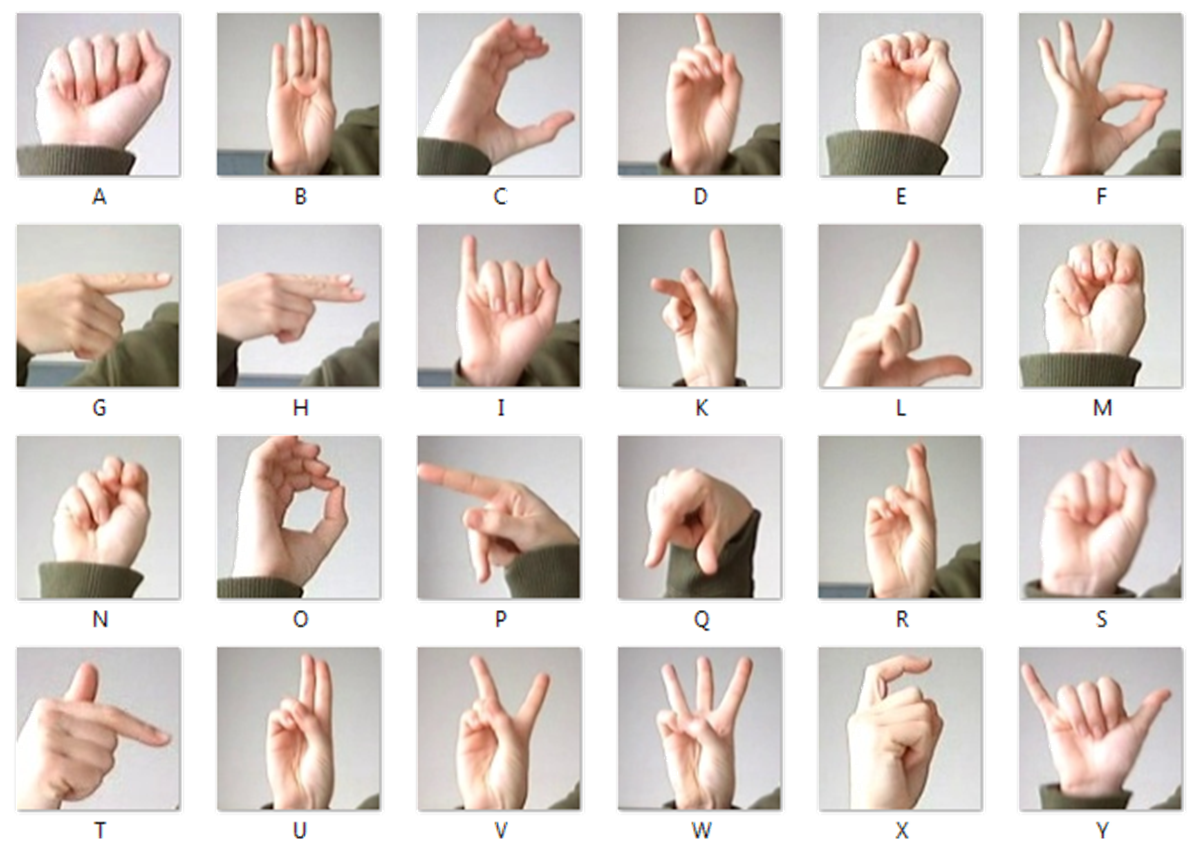

#### 1) 구글드라이브 연결

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### 2) 데이터 가져오기
* 제공 받은 데이터를 여러분의 구글드라이브 적절한 위치에 업로드 합니다.
    * 가능하면, 구글드라이브 첫 경로 밑에 폴더를 만들고 업로드 하기를 권장합니다.

In [4]:
path = '/content/drive/MyDrive/aivle/7차 미니프로젝트/data/sign_language.csv'

data = pd.read_csv(path)
data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [5]:
data.shape

(27455, 785)

#### 3) class names
* label이 0 ~ 27 까지의 숫자로 표현됩니다.
* 수어 중에서 J(9) 와 Z(27)는 손을 움직이면서 표현해야 하므로, 여기서는 제외합니다.
* 숫자로 레이블링 된 것을, 나중에 문자 변환하기 위해 문자로 된 리스트를 생성합니다.

In [6]:
import string
class_names = list(string.ascii_lowercase)
len(class_names), class_names

(26,
 ['a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z'])

## 2 데이터 살펴보기

* 데이터 한 건을 2차원으로 변환하고 그림 그리기

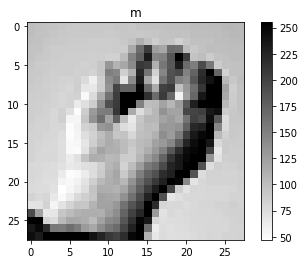

In [7]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 100
sign_fig = data.iloc[n, 1:].values
sign_fig = sign_fig.reshape(28, 28)

sign = class_names[data.iloc[n,0]]

plt.title(sign)
plt.imshow(255-sign_fig, cmap=plt.cm.binary)
plt.colorbar()
plt.show()

## 3.데이터 준비

* 주어진 데이터셋
    * 2차원 데이터셋, 1차원 데이터포인트(분석단위, 예측단위) 입니다. 
    * 흑백 이미지데이터
    * 이 데이터로부터 데이터 준비작업을 수행합니다.
        * 데이터 분할1 : x, y
        * 데이터 분할2 : train, validation
        * 만약 CNN으로 모델링을 한다면, shape를 맞춰야 합니다. (n, 28, 28, 1) 
        * scaling
* 그러나 운영에서 발생될 데이터는 이미지 한장 한장 입니다. 이미지 한장, 한장 들어온다면 어떻게 데이터가 처리되어야 할까요?(Data Pipeline 구성)

In [123]:
X=data.drop(columns='label',axis=1)
y=data['label']

In [124]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2022)

In [125]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(21964, 784) (5491, 784) (21964,) (5491,)


In [126]:
scaler = MinMaxScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [127]:
x_train_s.shape,y_train.shape

((21964, 784), (21964,))

In [128]:
y_train.unique()

array([17, 19, 10, 18, 11, 14,  6, 16, 23,  8,  4, 15, 13,  2,  7,  3, 12,
        0, 21, 20,  5,  1, 22, 24])

In [113]:
a=list(range(0,28))

In [143]:
y_train = pd.Categorical(y_train,categories=a,ordered=False)
y_test = pd.Categorical(y_test,categories=a,ordered=False)

In [144]:

from tensorflow.keras.utils import to_categorical

In [145]:
y_train = to_categorical(y_train, 28)
y_test = to_categorical(y_test, 28)

## 4.모델링
* 딥러닝을 이용하여 모델링 합시다.
* 머신러닝으로 모델링해도 됩니다.

### (1) DNN

In [15]:
from tensorflow import keras

In [116]:
clear_session()

il=keras.layers.Input(shape=(784,))
hl=keras.layers.Dense(256,activation="relu")(il)
hl=keras.layers.Dense(256,activation="relu")(hl)
ol=keras.layers.Dense(28,activation="sigmoid")(hl)

model=keras.models.Model(inputs=il,outputs=ol)

model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dense_2 (Dense)             (None, 28)                7196      
                                                                 
Total params: 273,948
Trainable params: 273,948
Non-trainable params: 0
_________________________________________________________________


In [17]:
import tensorflow
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
es=EarlyStopping(monitor='val_loss',
                 min_delta=0,
                 patience=3,
                 verbose=1,
                 restore_best_weights=True)

In [117]:
model.fit(x_train_s,y_train,epochs=50,validation_split=0.2,callbacks=[es])

Epoch 1/50
550/550 [==============================] - 3s 4ms/step - loss: 1.9971 - accuracy: 0.3810 - val_loss: 1.2928 - val_accuracy: 0.5773
Epoch 2/50
550/550 [==============================] - 2s 4ms/step - loss: 1.0560 - accuracy: 0.6585 - val_loss: 1.0349 - val_accuracy: 0.6342
Epoch 3/50
550/550 [==============================] - 2s 4ms/step - loss: 0.6590 - accuracy: 0.7889 - val_loss: 0.7837 - val_accuracy: 0.7334
Epoch 4/50
550/550 [==============================] - 2s 4ms/step - loss: 0.4406 - accuracy: 0.8589 - val_loss: 0.5586 - val_accuracy: 0.8076
Epoch 5/50
550/550 [==============================] - 2s 4ms/step - loss: 0.3354 - accuracy: 0.8963 - val_loss: 0.2436 - val_accuracy: 0.9297
Epoch 6/50
550/550 [==============================] - 2s 4ms/step - loss: 0.2161 - accuracy: 0.9342 - val_loss: 0.2674 - val_accuracy: 0.9224
Epoch 7/50
550/550 [==============================] - 2s 4ms/step - loss: 0.1492 - accuracy: 0.9574 - val_loss: 1.1610 - val_accuracy: 0.6631
Epoch 

In [62]:
score = model.evaluate(x_test_s, y_test, verbose=1)
print('\n', 'Test accuracy:', score[1])

172/172 [==============================] - 0s 2ms/step - loss: 0.0014 - accuracy: 1.0000

 Test accuracy: 1.0


### (2) CNN

In [146]:
x2=X.to_numpy()
x2=x2.reshape(27455,28,28,1)

In [147]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.2, random_state=2022)

In [148]:
x2_train.shape,y2_train.shape

((21964, 28, 28, 1), (21964,))

In [149]:
print(f'max : {x2_train.max()} , min : {x2_train.min()}')

max : 255 , min : 0


In [150]:
max_num = x2_train.max()

x2_train = x2_train/max_num
x2_test = x2_test/max_num

print(f'max : {x2_train.max()} , min : {x2_test.min()}')

max : 1.0 , min : 0.0


In [151]:
keras.backend.clear_session()

cnn=keras.models.Sequential()
cnn.add(keras.layers.Input(shape=(28,28,1)))
cnn.add(keras.layers.Conv2D(filters=32,padding="same",kernel_size=(3,3),strides=(1,1),activation="relu"))
cnn.add(keras.layers.Conv2D(filters=32,padding="same",kernel_size=(3,3),strides=(1,1),activation="relu"))
cnn.add(keras.layers.MaxPool2D(pool_size=(2,2)))
cnn.add(keras.layers.BatchNormalization())
cnn.add(keras.layers.Dropout(0.2))
cnn.add(keras.layers.Flatten())
cnn.add(keras.layers.Dense(28,activation="softmax"))
cnn.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='adam',
              metrics=['accuracy'])
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 14, 14, 32)       128       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 flatten (Flatten)           (None, 6272)              0

In [152]:
history = cnn.fit(x2_train, y_train, epochs=15, batch_size=1024,
                    validation_split=0.2, verbose=1,callbacks=[es])

Epoch 1/15
18/18 [==============================] - 1s 50ms/step - loss: 1.9529 - accuracy: 0.4532 - val_loss: 2.9958 - val_accuracy: 0.3988
Epoch 2/15
18/18 [==============================] - 1s 39ms/step - loss: 0.5897 - accuracy: 0.8432 - val_loss: 2.7323 - val_accuracy: 0.6183
Epoch 3/15
18/18 [==============================] - 1s 39ms/step - loss: 0.1991 - accuracy: 0.9619 - val_loss: 2.5206 - val_accuracy: 0.7917
Epoch 4/15
18/18 [==============================] - 1s 39ms/step - loss: 0.0702 - accuracy: 0.9935 - val_loss: 2.3478 - val_accuracy: 0.8789
Epoch 5/15
18/18 [==============================] - 1s 40ms/step - loss: 0.0320 - accuracy: 0.9993 - val_loss: 2.1282 - val_accuracy: 0.9511
Epoch 6/15
18/18 [==============================] - 1s 39ms/step - loss: 0.0184 - accuracy: 0.9998 - val_loss: 1.9504 - val_accuracy: 0.9838
Epoch 7/15
18/18 [==============================] - 1s 38ms/step - loss: 0.0113 - accuracy: 0.9998 - val_loss: 1.7567 - val_accuracy: 0.9916
Epoch 8/15
18

In [153]:
performance_test = cnn.evaluate(x2_test, y_test, batch_size=100)

print(f'Test Loss : {performance_test[0]:.6f},  Test Accuracy : {performance_test[1]*100:.3f}%')

55/55 [==============================] - 0s 4ms/step - loss: 0.4958 - accuracy: 0.9998
Test Loss : 0.495760,  Test Accuracy : 99.982%


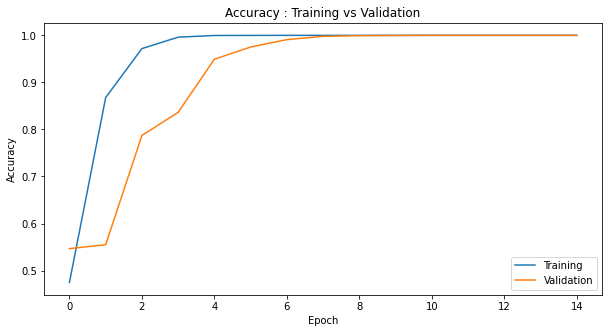

In [85]:
if not isinstance(history, dict) :
    history = history.history

plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Accuracy : Training vs Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc=0)
plt.show()

## 5.모델 저장하기

### (1) 모델 저장하기

In [45]:
model.save('/content/drive/MyDrive/aivle/7차 미니프로젝트/model/딥러닝_model1.h5')

In [154]:
cnn.save('/content/drive/MyDrive/aivle/7차 미니프로젝트/model/cnn.h5')

### (2) 모델 로딩하기

In [136]:
from keras.models import load_model

In [212]:
final_model=load_model('/content/drive/MyDrive/aivle/7차 미니프로젝트/model/cnn.h5')

In [213]:
final_model

* 불러온 모델 사용하기

In [158]:
final_model.evaluate(x2_test,y_test)

172/172 [==============================] - 1s 3ms/step - loss: 0.4958 - accuracy: 0.9998


[0.4957594871520996, 0.9998179078102112]

## 6.Data Pipeline 구성

### (1) 라이브러리 로딩

In [159]:
import cv2
from google.colab.patches import cv2_imshow

(1440, 1080)


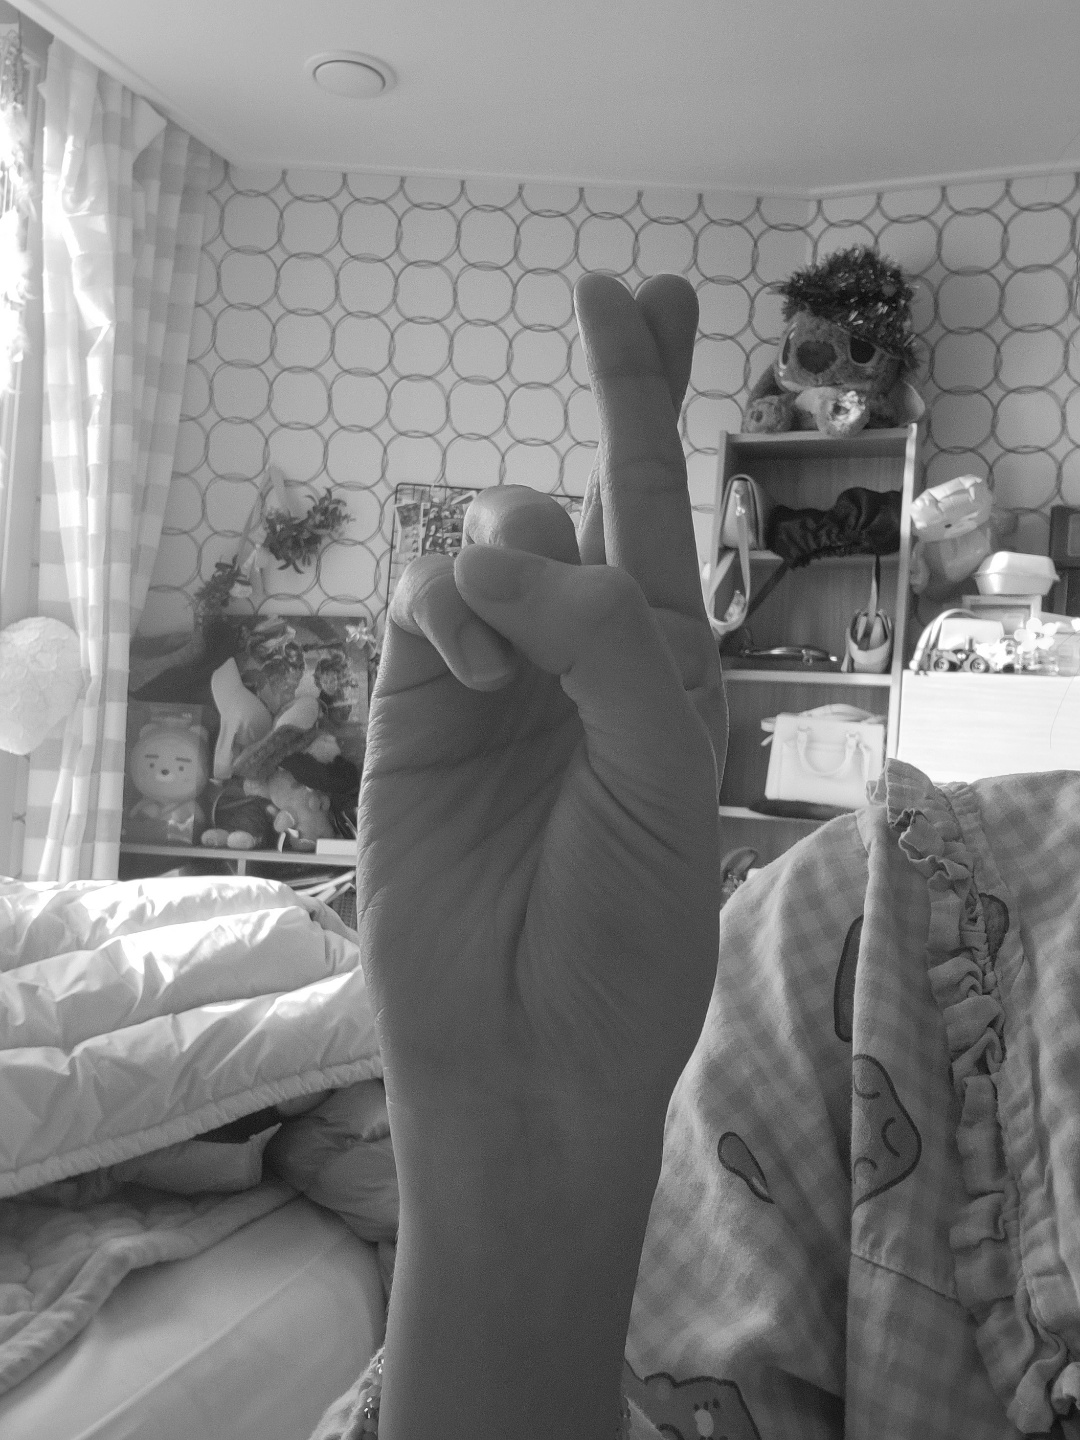

In [206]:
img=cv2.imread("/content/drive/MyDrive/aivle/7차 미니프로젝트/data/test image/me_R.jpg",cv2.IMREAD_GRAYSCALE)
print(img.shape)
cv2_imshow(img)

In [207]:
img=cv2.resize(img,(28,28))
cv2_imshow(img)

### (2) 테스트 데이터 로딩
* 제공받은 이미지로 테스트 해보기
* 직접 찍은 사진으로 테스트 해보기

### (3) Data Pipeline에 포함되어야 할 절차
* 이미지 크기 맞추기
* 흑백이미지
* 스케일링

In [208]:
img=img.reshape((1,28,28,1))

In [209]:
max_num = img.max()
img = img/max_num

In [214]:
y_pred=final_model.predict(img)

1/1 [==============================] - 0s 57ms/step


In [215]:
class_names[y_pred.argmax()]

'q'

### (4) 하나의 셀로 합치기

* 폴더 구조를 만들어 놓고 개발하기 필요한 코드를 하나로 모으기

In [216]:
def pipeline(file_path):
  from keras.models import load_model
  import numpy as np
  import pandas as pd
  import cv2

  class_names = list(string.ascii_lowercase)

  img=cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)
  img=cv2.resize(img,(28,28))
  img=img.reshape((1,28,28,1))
  max_num = img.max()
  img = img/max_num
  final_model=load_model('/content/drive/MyDrive/aivle/7차 미니프로젝트/model/cnn.h5')
  y_pred=final_model.predict(img)
  return class_names[y_pred.argmax()]

In [217]:
pipeline("/content/drive/MyDrive/aivle/7차 미니프로젝트/data/test image/me_i.jpg")

1/1 [==============================] - 0s 103ms/step


'y'